In [74]:
%matplotlib inline

import torch
from torch import nn
from torch.utils import data
from utils.train_model import train_net, sgd

In [ ]:
def generate_data_of_linear_regression_with_noise(n_inputs, n_train, n_test, batch_size = 256, W=None, b=None, noise=None):
    "Return: W, b, train_iter, test_iter"
    if W is None:
        W = torch.normal(0, 1, (n_inputs, 1))
    if b is None:
        b = torch.zeros(1)
    if noise is None:
        noise = torch.normal(0, 0.01, (n_train + n_test, 1))
    Xs = torch.normal(0, 1, (n_train + n_test, n_inputs))
    Ys = Xs @ W + b + noise
    train_iter = data.DataLoader(data.TensorDataset(Xs[:n_train], Ys[:n_train]), batch_size=batch_size, shuffle=True)
    test_iter = data.DataLoader(data.TensorDataset(Xs[n_train:], Ys[n_train:]), batch_size=batch_size, shuffle=False)
    return W, b, train_iter, test_iter

n_inputs, n_train, n_test, n_example, batch_size = 200, 20, 100, 3, 256
true_W, true_b, train_iter, test_iter = generate_data_of_linear_regression_with_noise(n_inputs, n_train, n_test, batch_size)


In [76]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using {device} device")

Using cuda device


In [ ]:
def l2_penalty(w):
    return torch.sum(w.pow(2)) / 2

def sgd_with_l2(params, lr, batch_size, lambd):
    params = list(params)
    with torch.no_grad():
        for param in params:
            param -= lr * (param.grad / batch_size + lambd * param)
            param.grad.zero_()
                
net = nn.Linear(n_inputs, 1)
net = net.to(device)
net_with_l2 = nn.Linear(n_inputs, 1)
net_with_l2 = net_with_l2.to(device)
loss = nn.MSELoss()
lambd = 3
lr = 0.01
num_epochs = 200

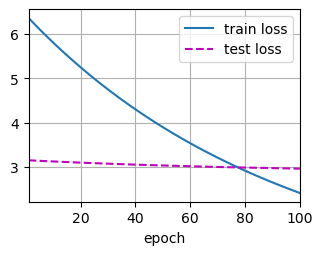

epoch 100, train loss 2.413, test loss 2.962


In [78]:
train_net(net, train_iter, test_iter, loss, net_type='Regression', num_epochs=num_epochs, device=device, updater = lambda batch_size: sgd(net.parameters(), lr=lr, batch_size=batch_size))

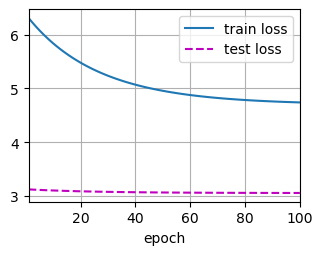

epoch 100, train loss 4.739, test loss 3.059


In [79]:
train_net(net_with_l2, train_iter, test_iter, loss, net_type='Regression', num_epochs=num_epochs, device=device, updater=lambda batch_size: sgd_with_l2(net_with_l2.parameters(), lr=lr, batch_size=batch_size, lambd=lambd))

# Simple implementation

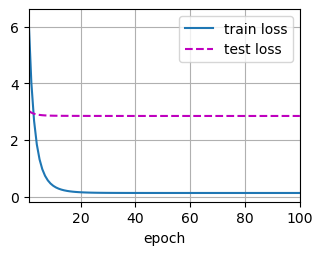

epoch 100, train loss 0.127, test loss 2.849


In [80]:
net_simple = nn.Sequential(nn.Linear(n_inputs, 1))
net_simple = net_simple.to(device)
trainer = torch.optim.SGD(
    [
        {'params': net_simple[0].weight, 'weight_decay': lambd},
        {'params': net_simple[0].bias}
    ],
    lr=lr
)
train_net(net_simple, train_iter, test_iter, loss, net_type='Regression', num_epochs=num_epochs, device=device, updater=trainer)